# Entrenamiento del modelo — Dataset TechMind

TF-IDF + Regresión Logística vs. Naive Bayes, con ajuste de hiperparámetros para ambos, selección justificada del mejor modelo por F1 macro, validación cruzada y entregables guardados en `joblib`.

Requiere `dataset_limpio_techmind_v2.csv` en la misma carpeta.

In [22]:
import time
import joblib
import numpy as np
import pandas as pd
from datetime import date
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

In [23]:
df = pd.read_csv('dataset_limpio_techmind_v2.csv')
df.head()

,titulo_limpio,texto_limpio,categoria_final,palabras_clave,fuente,idioma
0,How to convert RGB matrix to binary array in M...,I wrote a code to convert imagejpg to binary u...,Ciencia de Datos,matlab,stackoverflow,en
1,Why is this call is ambiguous between the foll...,Error CS0121 The call is ambiguous between the...,DevOps / Cloud,"c#, azure, dependency-injection",stackoverflow,en
2,Our failure story with Redis operator for K8s ...,What will happen if you use a well-known and e...,DevOps / Cloud,"['DevOps', 'Kubernetes Operator', 'Kubernetes'...",medium,en
3,spatial temporal interpolarization,Assume I have a spatial temporal dataframe whi...,Ciencia de Datos,"r, interpolation, spatial",stackoverflow,en
4,Why does the method worldposition in SCNKit no...,I would like to get the position of a SCNNode ...,Mobile,"ios, swift, arkit",stackoverflow,en


## 1. Preparar los datos para entrenamiento

In [24]:
# se utilizan las dos collumnas de titulo_limpio mas texto_limpio
df = df.dropna(subset=["texto_limpio", "categoria_final"])
df['titulo_limpio'] = df['titulo_limpio'].fillna('')

X = df['titulo_limpio'] + ' ' + df['texto_limpio']
y = df['categoria_final']

print(f"Registros cargados para entrenamiento: {len(df)}")
print(df["categoria_final"].value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"\nTrain: {len(X_train)} registros | Test: {len(X_test)} registros")
print("\nDistribucion de clases en TEST (distribucion real, sin forzar balance):")
print(y_test.value_counts())

Registros cargados para entrenamiento: 38257
categoria_final
Frontend                5396
Ciencia de Datos        5277
DevOps / Cloud          5239
Programación General    5184
Backend                 5085
Mobile                  5048
Bases de Datos          4236
Seguridad               2792
Name: count, dtype: int64

Train: 30605 registros | Test: 7652 registros

Distribucion de clases en TEST (distribucion real, sin forzar balance):
categoria_final
Frontend                1079
Ciencia de Datos        1056
DevOps / Cloud          1048
Programación General    1037
Backend                 1017
Mobile                  1010
Bases de Datos           847
Seguridad                558
Name: count, dtype: int64


##2. Línea base (baseline)

In [25]:
# Se agrega dummyClassifer para saber si 0.75 de F1 es bueno o malo.
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

### 3. Aplicar TF-IDF

In [26]:
# 60,000 featuresterminos es poco vocabulario y deja fuera variantes tecnicas validas.
vector = TfidfVectorizer(max_features=60000, min_df=5, ngram_range=(1, 2))
X_train_tfidf = vector.fit_transform(X_train)
X_test_tfidf = vector.transform(X_test)
print(f'\ndimensiones del entrenamiento TF-IDF: {X_train_tfidf.shape}')
print(f'dimensiones del test TF-IDF: {X_test_tfidf.shape}')


dimensiones del entrenamiento TF-IDF: (30605, 60000)
dimensiones del test TF-IDF: (7652, 60000)


## 4. Entrenar Regresión Logística

In [27]:
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

## 5. Evaluar Naive Bayes como alternativa

In [28]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

## 6. Calcular métricas (Accuracy, Precision, Recall, F1)

In [29]:
def evaluar_modelo(y_true, y_pred, nombre_modelo, mostrar_reporte=False):
    # F1 macro trata a todas las categorias por igual (incluida la minoritaria,
    # Seguridad); F1 weighted pondera por tamano de clase y puede disimular
    # un mal desempeno en las clases chicas. Se calculan ambos, pero macro
    # es el criterio principal para elegir el mejor modelo.
    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    prec_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"--- Métricas para {nombre_modelo} ---")
    print(f"Accuracy         : {acc:.4f}")
    print(f"Precision (macro): {prec_macro:.4f}  | (weighted): {prec_weighted:.4f}")
    print(f"Recall    (macro): {rec_macro:.4f}  | (weighted): {rec_weighted:.4f}")
    print(f"F1 Score  (macro): {f1_macro:.4f}  | (weighted): {f1_weighted:.4f}\n")

    if mostrar_reporte:
        print(classification_report(y_true, y_pred, zero_division=0))

    return {
        'Modelo': nombre_modelo,
        'Accuracy': acc,
        'Precision_macro': prec_macro,
        'Recall_macro': rec_macro,
        'F1_macro': f1_macro,
        'Precision_weighted': prec_weighted,
        'Recall_weighted': rec_weighted,
        'F1_weighted': f1_weighted,
    }
res_dummy = evaluar_modelo(y_test, y_pred_dummy, "Baseline (clase mas frecuente)")
res_lr = evaluar_modelo(y_test, y_pred_lr, "Regresión Logística (base)")
res_nb = evaluar_modelo(y_test, y_pred_nb, "Naive Bayes (base)")

--- Métricas para Baseline (clase mas frecuente) ---
Accuracy         : 0.1410
Precision (macro): 0.0176  | (weighted): 0.0199
Recall    (macro): 0.1250  | (weighted): 0.1410
F1 Score  (macro): 0.0309  | (weighted): 0.0349

--- Métricas para Regresión Logística (base) ---
Accuracy         : 0.7470
Precision (macro): 0.7570  | (weighted): 0.7512
Recall    (macro): 0.7428  | (weighted): 0.7470
F1 Score  (macro): 0.7482  | (weighted): 0.7479

--- Métricas para Naive Bayes (base) ---
Accuracy         : 0.6683
Precision (macro): 0.6989  | (weighted): 0.6856
Recall    (macro): 0.6534  | (weighted): 0.6683
F1 Score  (macro): 0.6634  | (weighted): 0.6688



## 7. Comparar diferentes algoritmos

In [30]:
resultados = [res_dummy, res_lr, res_nb]
df_comparativa = pd.DataFrame(resultados)
print("--- Comparativa (baseline + modelos base) ---")
print(df_comparativa.round(4))

--- Comparativa (baseline + modelos base) ---
                           Modelo  Accuracy  Precision_macro  Recall_macro  \
0  Baseline (clase mas frecuente)    0.1410           0.0176        0.1250   
1      Regresión Logística (base)    0.7470           0.7570        0.7428   
2              Naive Bayes (base)    0.6683           0.6989        0.6534   

   F1_macro  Precision_weighted  Recall_weighted  F1_weighted  
0    0.0309              0.0199           0.1410       0.0349  
1    0.7482              0.7512           0.7470       0.7479  
2    0.6634              0.6856           0.6683       0.6688  


## 8. Ajustar hiperparámetros

In [31]:
# El GridSearch se hace sobre un Pipeline (tfidf + clf), no sobre una
# matriz ya vectorizada: si el TF-IDF se ajusta una sola vez antes de
# partir en folds, cada fold de validacion ya "vio" vocabulario del
# resto del train a traves del IDF, y el resultado de la validacion
# cruzada sale optimista. Con el Pipeline, el TF-IDF se reajusta en
# cada fold usando solo esa porcion de entrenamiento.
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=60000, min_df=5, ngram_range=(1, 2))),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
param_grid_lr = {'clf__C': [1.0, 4.0]}
# Nota: se usa 'lbfgs' (el solver por defecto) porque 'liblinear' no
# soporta clasificacion multiclase nativa con 8 categorias.
inicio = time.time()
grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=3, scoring='f1_macro', n_jobs=-1)
grid_lr.fit(X_train, y_train)
tiempo_grid_lr = time.time() - inicio
pipe_lr_ajustado = grid_lr.best_estimator_
print(f"Mejores hiperparámetros (Regresión Logística): {grid_lr.best_params_} "
      f"({tiempo_grid_lr:.1f}s)")

y_pred_mejor_lr = pipe_lr_ajustado.predict(X_test)
res_lr_ajustado = evaluar_modelo(y_test, y_pred_mejor_lr, "Regresión Logística (ajustada)")
resultados.append(res_lr_ajustado)

pipe_nb = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=60000, min_df=5, ngram_range=(1, 2))),
    ('clf', MultinomialNB()),
])
param_grid_nb = {'clf__alpha': [0.5, 1.0]}
inicio = time.time()
grid_nb = GridSearchCV(pipe_nb, param_grid_nb, cv=3, scoring='f1_macro', n_jobs=-1)
grid_nb.fit(X_train, y_train)
tiempo_grid_nb = time.time() - inicio
pipe_nb_ajustado = grid_nb.best_estimator_
print(f"Mejores hiperparámetros (Naive Bayes): {grid_nb.best_params_} "
      f"({tiempo_grid_nb:.1f}s)")

y_pred_mejor_nb = pipe_nb_ajustado.predict(X_test)
res_nb_ajustado = evaluar_modelo(y_test, y_pred_mejor_nb, "Naive Bayes (ajustado)")
resultados.append(res_nb_ajustado)

df_comparativa = pd.DataFrame(resultados)
print("--- Comparativa completa (baseline + base + ajustados) ---")
print(df_comparativa.round(4))

Mejores hiperparámetros (Regresión Logística): {'clf__C': 4.0} (453.9s)
--- Métricas para Regresión Logística (ajustada) ---
Accuracy         : 0.7516
Precision (macro): 0.7598  | (weighted): 0.7547
Recall    (macro): 0.7484  | (weighted): 0.7516
F1 Score  (macro): 0.7531  | (weighted): 0.7524

Mejores hiperparámetros (Naive Bayes): {'clf__alpha': 0.5} (198.6s)
--- Métricas para Naive Bayes (ajustado) ---
Accuracy         : 0.6734
Precision (macro): 0.6868  | (weighted): 0.6823
Recall    (macro): 0.6640  | (weighted): 0.6734
F1 Score  (macro): 0.6713  | (weighted): 0.6749

--- Comparativa completa (baseline + base + ajustados) ---
                           Modelo  Accuracy  Precision_macro  Recall_macro  \
0  Baseline (clase mas frecuente)    0.1410           0.0176        0.1250   
1      Regresión Logística (base)    0.7470           0.7570        0.7428   
2              Naive Bayes (base)    0.6683           0.6989        0.6534   
3  Regresión Logística (ajustada)    0.7516      

## 8. Seleccionar el mejor modelo

In [32]:
# Se elige por F1 macro para no premiar a un modelo que solo acierta
# bien en las categorias grandes.
idx_mejor = df_comparativa['F1_macro'].idxmax()
nombre_mejor = df_comparativa.loc[idx_mejor, 'Modelo']

candidatos = {
    "Baseline (clase mas frecuente)": dummy,
    "Regresión Logística (base)": Pipeline([('tfidf', vector), ('clf', lr_model)]),
    "Naive Bayes (base)": Pipeline([('tfidf', vector), ('clf', nb_model)]),
    "Regresión Logística (ajustada)": pipe_lr_ajustado,
    "Naive Bayes (ajustado)": pipe_nb_ajustado,
}
modelo_final = candidatos[nombre_mejor]

print(f"\nMEJOR MODELO SELECCIONADO: {nombre_mejor}")
print(f"F1 macro: {df_comparativa.loc[idx_mejor, 'F1_macro']:.4f}")
print(f"(Referencia — baseline: {res_dummy['F1_macro']:.4f}, "
      f"el modelo elegido es {df_comparativa.loc[idx_mejor, 'F1_macro'] / res_dummy['F1_macro']:.1f}x mejor que el azar)")

y_pred_final = modelo_final.predict(X_test)
print(f"\n--- Reporte detallado por clase: {nombre_mejor} ---")
print(classification_report(y_test, y_pred_final, zero_division=0))


MEJOR MODELO SELECCIONADO: Regresión Logística (ajustada)
F1 macro: 0.7531
(Referencia — baseline: 0.0309, el modelo elegido es 24.4x mejor que el azar)

--- Reporte detallado por clase: Regresión Logística (ajustada) ---
                      precision    recall  f1-score   support

             Backend       0.62      0.64      0.63      1017
      Bases de Datos       0.84      0.83      0.83       847
    Ciencia de Datos       0.79      0.82      0.81      1056
      DevOps / Cloud       0.73      0.72      0.72      1048
            Frontend       0.81      0.80      0.81      1079
              Mobile       0.86      0.84      0.85      1010
Programación General       0.62      0.66      0.64      1037
           Seguridad       0.82      0.67      0.74       558

            accuracy                           0.75      7652
           macro avg       0.76      0.75      0.75      7652
        weighted avg       0.75      0.75      0.75      7652



## 10. Validar resultados (validación cruzada sobre el Pipeline)

In [33]:
# Igual que en el ajuste de hiperparametros: se valida sobre el Pipeline con texto crudo, para que el TF-IDF se reajuste en cada fold.
scores_cv = cross_val_score(
    modelo_final, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1
)
print(f"\nValidación cruzada (5-fold) sobre TRAIN — F1 macro: "
      f"{scores_cv.mean():.4f} (+/- {scores_cv.std():.4f})")
print("Esto confirma si el desempeño en test fue consistente o resultado del azar del split.")


Validación cruzada (5-fold) sobre TRAIN — F1 macro: 0.7506 (+/- 0.0024)
Esto confirma si el desempeño en test fue consistente o resultado del azar del split.


## 11. Generar la matriz de confusión

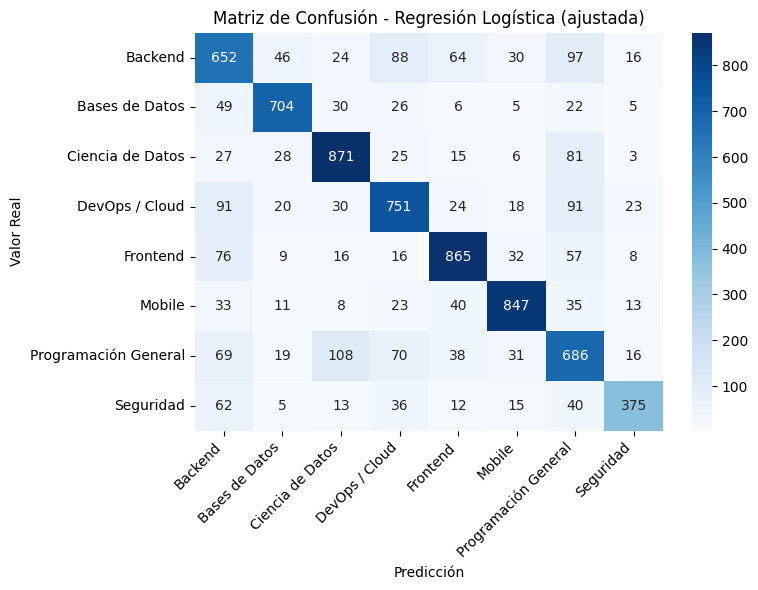

In [34]:
plt.figure(figsize=(8, 6))
etiquetas = modelo_final.named_steps['clf'].classes_ if hasattr(modelo_final, 'named_steps') else modelo_final.classes_
cm = confusion_matrix(y_test, y_pred_final, labels=etiquetas)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=etiquetas, yticklabels=etiquetas)
plt.title(f'Matriz de Confusión - {nombre_mejor}')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('matriz_de_confusion.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Términos más decisivos por categoría

In [35]:
# Con los pesos del clasificador (coef_ en Regresion Logistica, o
# feature_log_prob_ en Naive Bayes) se puede ver que vocabulario
# definio cada categoria: es la evidencia de que el modelo aprendio
# semantica tecnica real y no solo correlaciones superficiales.
terminos_por_categoria = {}
if hasattr(modelo_final, 'named_steps'):
    clf_final = modelo_final.named_steps['clf']
    tfidf_final = modelo_final.named_steps['tfidf']
    vocabulario = tfidf_final.get_feature_names_out()

    if hasattr(clf_final, 'coef_'):
        pesos = clf_final.coef_
        clases = clf_final.classes_
        print("--- Términos más decisivos por categoría (coeficientes de Regresión Logística) ---")
        for i, categoria in enumerate(clases):
            top_idx = np.argsort(pesos[i])[::-1][:12]
            terminos = [vocabulario[j] for j in top_idx]
            terminos_por_categoria[categoria] = terminos
            print(f"{categoria}: {', '.join(terminos)}")
    elif hasattr(clf_final, 'feature_log_prob_'):
        log_prob = clf_final.feature_log_prob_
        clases = clf_final.classes_
        print("--- Términos más decisivos por categoría (log-prob de Naive Bayes) ---")
        for i, categoria in enumerate(clases):
            top_idx = np.argsort(log_prob[i])[::-1][:12]
            terminos = [vocabulario[j] for j in top_idx]
            terminos_por_categoria[categoria] = terminos
            print(f"{categoria}: {', '.join(terminos)}")
else:
    print("El modelo seleccionado (baseline) no tiene vocabulario ni pesos que analizar.")

--- Términos más decisivos por categoría (coeficientes de Regresión Logística) ---
Backend: laravel, spring, java, php, rails, go, ruby, scala, golang, net, woocommerce, gem
Bases de Datos: sql, redis, mysql, query, elasticsearch, table, database, mongodb, postgresql, oracle, sqlite, procedure
Ciencia de Datos: spark, matlab, dataframe, plot, shiny, ai, data, opencv, numpy, dataset, ggplot, simulink
DevOps / Cloud: azure, linux, cmake, sbt, aws, docker, kubernetes, powershell, terraform, gradle, s3, bash
Frontend: javascript, typescript, css, angular, js, html, ts, react, component, vue, design, chrome
Mobile: swift, android, swiftui, kotlin, ios, xcode, flutter, app, view, compose, react native, in swift
Programación General: perl, rust, python, clang, crate, gcc, software, in python, programming, windows, program, trait
Seguridad: security, openssl, hash, keycloak, encrypted, cybersecurity, ssl, encryption, malware, jwt, tls, attack


## 13. Guardar entregables (Pipeline único)

In [36]:
# Se guarda UN SOLO Pipeline (tfidf + clf), no el modelo y el
# vectorizador por separado: el backend espera un objeto con
# modelo.predict_proba(texto_crudo) y modelo.named_steps["tfidf"].
if not hasattr(modelo_final, 'named_steps'):
    # Si por alguna razon el baseline ganara, se envuelve igual en un
    # Pipeline (con un tfidf sin usar) para mantener la misma interfaz.
    modelo_final = Pipeline([('tfidf', vector), ('clf', modelo_final)])

joblib.dump(modelo_final, 'modelo_techmind_v2.joblib')
print("\n-> Archivo guardado: modelo_techmind_v2.joblib (Pipeline completo: tfidf + clf)")

resultados_entrenamiento = {
    "nombre_mejor_modelo": nombre_mejor,
    "comparativa": df_comparativa.to_dict(orient="records"),
    "mejores_hiperparametros_lr": grid_lr.best_params_,
    "mejores_hiperparametros_nb": grid_nb.best_params_,
    "cv_f1_macro_mean": scores_cv.mean(),
    "cv_f1_macro_std": scores_cv.std(),
    "matriz_confusion": cm.tolist(),
    "etiquetas": list(etiquetas),
    "terminos_por_categoria": terminos_por_categoria,
}
joblib.dump(resultados_entrenamiento, 'resultados_entrenamiento.joblib')
print("-> Archivo guardado: resultados_entrenamiento.joblib")

df_comparativa.round(4).to_csv('metricas_rendimiento.csv', index=False)
print("-> Archivo guardado: metricas_rendimiento.csv")


-> Archivo guardado: modelo_techmind_v2.joblib (Pipeline completo: tfidf + clf)
-> Archivo guardado: resultados_entrenamiento.joblib
-> Archivo guardado: metricas_rendimiento.csv


## 14. Documentar el proceso de entrenamiento

In [37]:
informe = f"""# Informe Técnico de Entrenamiento — Dataset TechMind (v4)

Fecha de generación: {date.today()}

## Datos utilizados
- Fuente: `dataset_limpio_techmind_v2.csv` (dataset limpio, no el balanceado)
- Registros totales: {len(df)}
- Entrada del modelo: `titulo_limpio + ' ' + texto_limpio` (antes solo se usaba
  el texto; se combinó porque la API en producción manda ambos campos juntos)
- Train: {len(X_train)} | Test: {len(X_test)} (split 80/20 estratificado)
- Categorías: {len(etiquetas)} ({', '.join(etiquetas)})

## Vectorización
- TF-IDF, max_features=60000 (antes 5000), min_df=5, n-gramas (1,2)
- Dimensión resultante: {X_train_tfidf.shape[1]} términos

## Línea base (baseline)
- `DummyClassifier(strategy='most_frequent')` — F1 macro: {res_dummy['F1_macro']:.4f}
- Referencia para interpretar si el resto de los modelos realmente aprendió algo.

## Modelos evaluados
1. Regresión Logística (base)
2. Naive Bayes / MultinomialNB (base)
3. Regresión Logística (ajustada vía GridSearchCV sobre el Pipeline completo,
   cv=3, scoring=f1_macro) — mejores hiperparámetros: {grid_lr.best_params_}
4. Naive Bayes (ajustado vía GridSearchCV sobre el Pipeline completo,
   cv=3, scoring=f1_macro) — mejores hiperparámetros: {grid_nb.best_params_}

El ajuste de hiperparámetros y la validación cruzada se corrieron sobre el
Pipeline completo (texto crudo → TF-IDF → clasificador), no sobre una matriz
TF-IDF ya ajustada, para que el vectorizador se reajuste en cada fold y no
haya fuga de información entre folds.

## Comparativa de resultados (test)
{df_comparativa.round(4).to_markdown(index=False)}

## Selección del mejor modelo
**{nombre_mejor}**, con F1 macro = {df_comparativa.loc[idx_mejor, 'F1_macro']:.4f},
frente a un baseline de {res_dummy['F1_macro']:.4f}
({df_comparativa.loc[idx_mejor, 'F1_macro'] / res_dummy['F1_macro']:.1f}x mejor que predecir siempre la clase mayoritaria).

## Validación cruzada (5-fold, sobre train, con Pipeline completo)
- F1 macro: {scores_cv.mean():.4f} (+/- {scores_cv.std():.4f})

## Términos más decisivos por categoría
Extraídos de los coeficientes/log-probabilidades del clasificador final,
confirman que el modelo aprendió vocabulario técnico coherente por categoría
(ver detalle en `resultados_entrenamiento.joblib`, clave `terminos_por_categoria`).

## Entregables generados
- `modelo_techmind_v2.joblib` — **Pipeline único** (tfidf + clf), compatible
  con `modelo.predict_proba(texto_crudo)` y `modelo.named_steps["tfidf"]`
- `resultados_entrenamiento.joblib` (comparativa, hiperparámetros, matriz de
  confusión, validación cruzada y términos decisivos por categoría)
- `metricas_rendimiento.csv` (comparativa entre modelos, versión legible)
- `matriz_de_confusion.png`
- Este informe (`informe_entrenamiento.md`)
"""

with open('informe_entrenamiento.md', 'w', encoding='utf-8') as f:
    f.write(informe)
print("-> Archivo guardado: informe_entrenamiento.md")

print("\n=== PROCESO DE ENTRENAMIENTO FINALIZADO ===")

-> Archivo guardado: informe_entrenamiento.md

=== PROCESO DE ENTRENAMIENTO FINALIZADO ===
